# Marketing ROI Analysis

In this project, we will analyze a marketing dataset using Python and statsmodels to build a Simple Linear Regression model.

### Import libraries Data

In [15]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from scipy import stats

### Load Data

In [10]:


def wrangle(filepath:str):
    df = pd.read_csv(filepath)
    
    #handle missing values
    df.fillna(df.mean(numeric_only=True), inplace=True)

    return df

### Overview

In [11]:
marketing = wrangle("./data/marketing_and_sales.csv")

marketing.head()

,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


### Check Missing Values

In [13]:
marketing.isna().sum()


TV              0
Radio           0
Social_Media    0
Sales           0
dtype: int64

### Exploratory data analysis

### pair plot

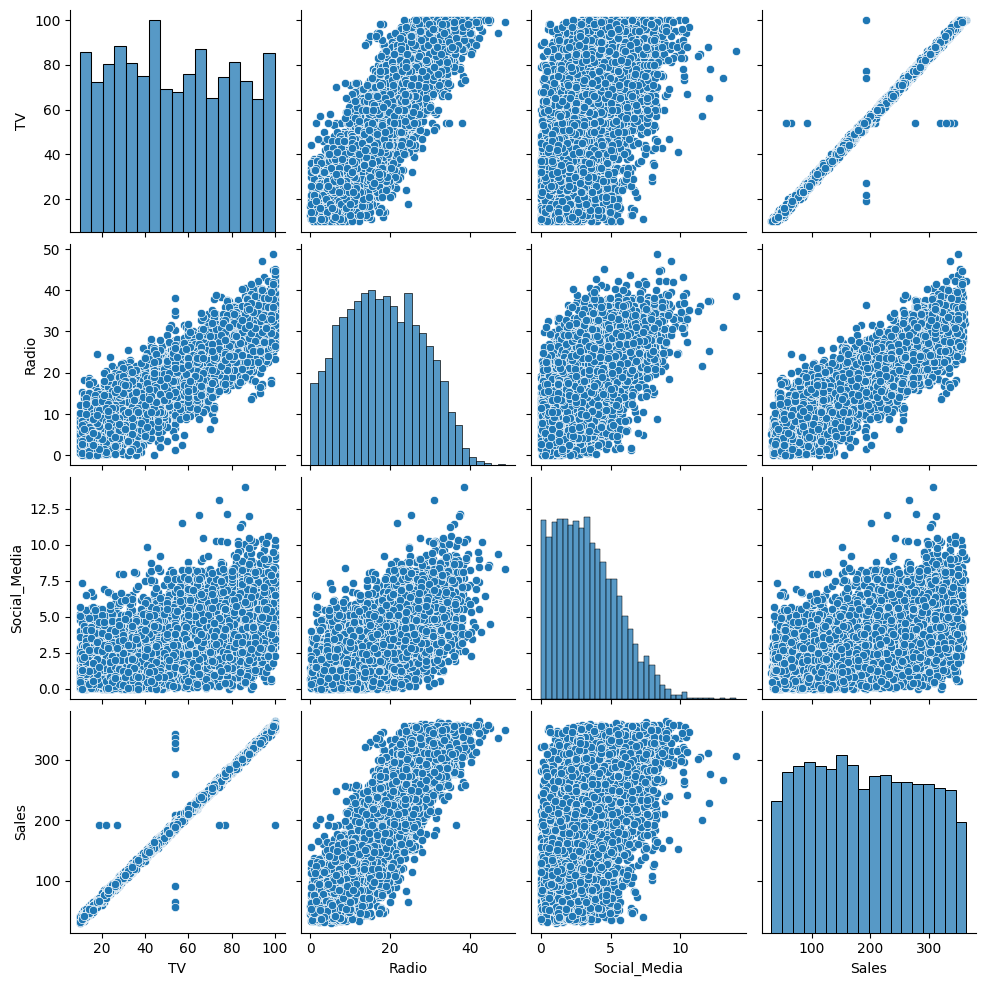

In [16]:
sns.pairplot(marketing)
plt.show()

### Correlation Matrix

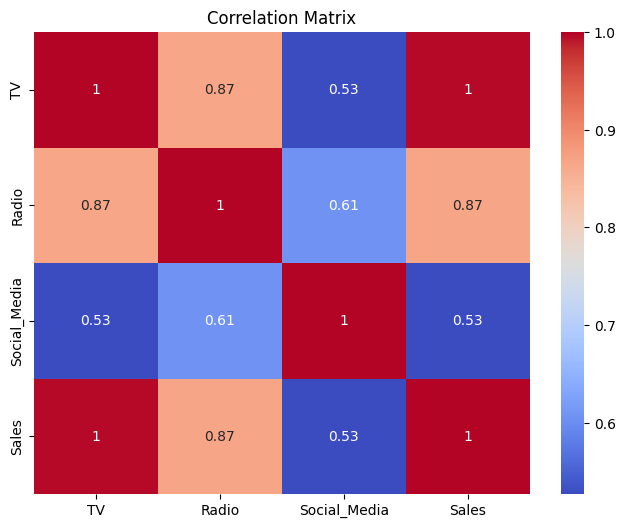

In [17]:
corr_matrix = marketing.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [18]:
marketing.corr(numeric_only=True)["Sales"].sort_values(ascending=False)

Sales           1.000000
TV              0.996652
Radio           0.867369
Social_Media    0.528121
Name: Sales, dtype: float64

In [21]:
X = marketing["TV"]
y = marketing["Sales"]

#### Visualize Selected Relationship

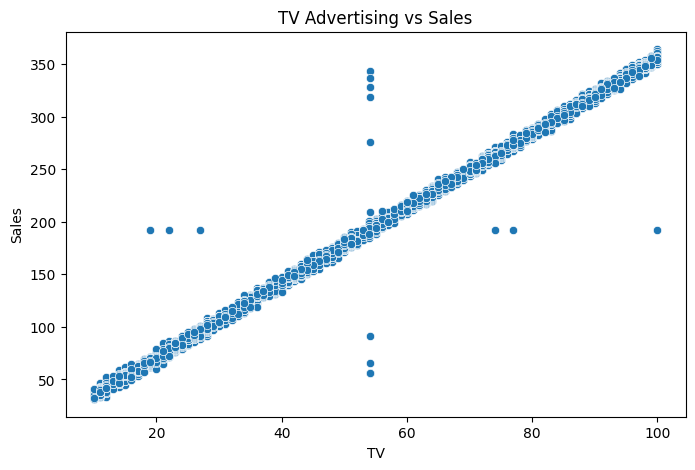

In [19]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=marketing, x="TV", y="Sales")

plt.title("TV Advertising vs Sales")
plt.show()

### Build Simple Linear Regression Model

In [22]:
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

In [23]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.993
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                 6.792e+05
Date:                Tue, 02 Jun 2026   Prob (F-statistic):               0.00
Time:                        23:19:29   Log-Likelihood:                -15765.
No. Observations:                4572   AIC:                         3.153e+04
Df Residuals:                    4570   BIC:                         3.155e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2849      0.259      1.100      0.2